In [1]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/alaramyaseshasri/palm-features-clean/palm_features_clean.csv


In [2]:
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/alaramyaseshasri/palm-features-clean/palm_features_clean.csv")

print(df.shape)
df.head()

(2864, 9)


,filename,palm_width,palm_height,thumb_length,index_length,middle_length,ring_length,little_length,aspect_ratio
0,Hand_0000002.jpg,0.260342,0.438580,0.440385,0.490586,0.546106,0.515422,0.403868,1.684625
1,Hand_0000003.jpg,0.263889,0.434762,0.437788,0.484436,0.535702,0.506209,0.403088,1.647516
2,Hand_0000004.jpg,0.252337,0.409462,0.434339,0.482815,0.544500,0.507708,0.401512,1.622681
3,Hand_0000005.jpg,0.251028,0.410806,0.458526,0.494063,0.553957,0.514012,0.405956,1.636494
4,Hand_0000006.jpg,0.258284,0.417347,0.444654,0.475146,0.534538,0.504858,0.394475,1.615841


In [3]:
# Remove filename column
X = df.drop("filename", axis=1)

print("Feature Shape:", X.shape)

X.head()

Feature Shape: (2864, 8)


,palm_width,palm_height,thumb_length,index_length,middle_length,ring_length,little_length,aspect_ratio
0,0.260342,0.438580,0.440385,0.490586,0.546106,0.515422,0.403868,1.684625
1,0.263889,0.434762,0.437788,0.484436,0.535702,0.506209,0.403088,1.647516
2,0.252337,0.409462,0.434339,0.482815,0.544500,0.507708,0.401512,1.622681
3,0.251028,0.410806,0.458526,0.494063,0.553957,0.514012,0.405956,1.636494
4,0.258284,0.417347,0.444654,0.475146,0.534538,0.504858,0.394475,1.615841


In [4]:
from sklearn.preprocessing import StandardScaler

X = X.astype("float32")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Shape:", X_scaled.shape)

Scaled Shape: (2864, 8)


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

PCA Shape: (2864, 2)


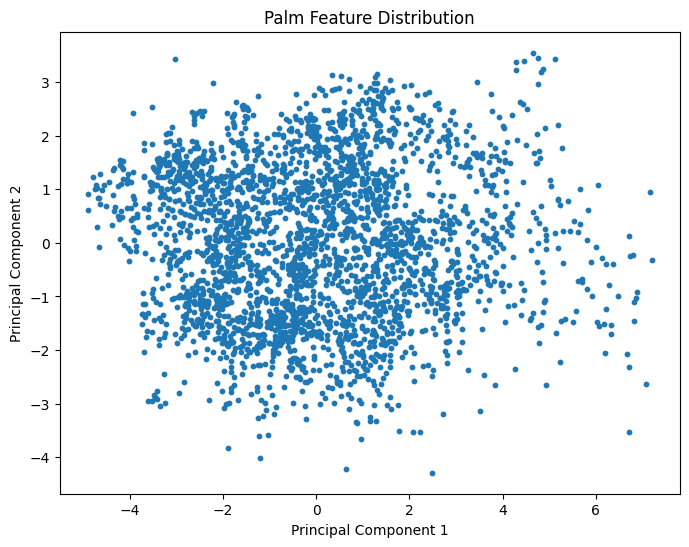

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=10
)

plt.title("Palm Feature Distribution")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [7]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(X_scaled)

print("KMeans Model Trained Successfully!")

KMeans Model Trained Successfully!


In [8]:
#Predict Clusters
clusters = kmeans.predict(X_scaled)

print(clusters[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2]


In [9]:
#Add Cluster Column
df["Cluster"] = clusters

print(df["Cluster"].value_counts())

Cluster
3    709
4    646
1    612
2    582
0    315
Name: count, dtype: int64


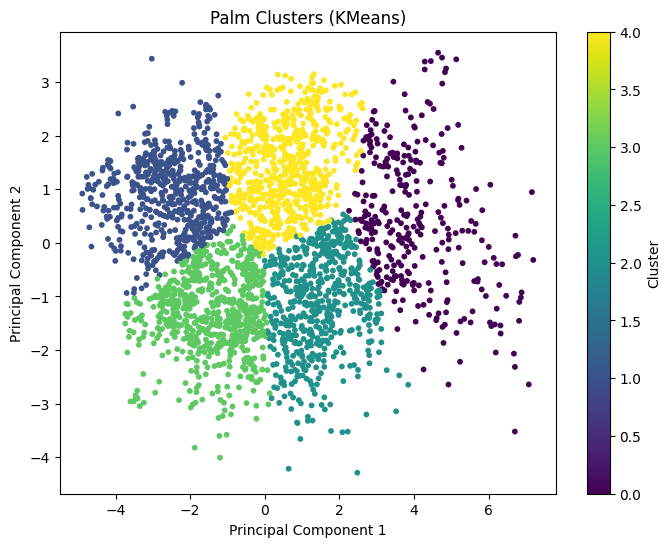

In [10]:
#Cluster Visualization
plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=10
)

plt.title("Palm Clusters (KMeans)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [11]:
#Cluster Summary
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

print(cluster_summary)

         palm_width  palm_height  thumb_length  index_length  middle_length  \
Cluster                                                                       
0          0.272068     0.453067      0.463816      0.487875       0.536770   
1          0.203911     0.395479      0.379504      0.342890       0.375304   
2          0.236996     0.374186      0.384353      0.438290       0.490144   
3          0.204853     0.334428      0.341509      0.377556       0.420617   
4          0.238777     0.449585      0.435843      0.408596       0.443584   

         ring_length  little_length  aspect_ratio  
Cluster                                            
0           0.500974       0.395405      1.670120  
1           0.346259       0.276808      1.949347  
2           0.457075       0.357745      1.580157  
3           0.392980       0.308147      1.636097  
4           0.410834       0.329723      1.891273  


In [12]:
df.to_csv("/kaggle/working/palm_clustered.csv", index=False)

cluster_summary.to_csv("/kaggle/working/palm_cluster_summary.csv", index=False)

print("Files Saved Successfully!")

Files Saved Successfully!
